# Deep Learning Model

This notebook implements and evaluates a feedforward Artificial Neural Network (ANN) for multiclass cancer classification using the selected transcriptomic biomarker panel.

The neural network is trained using the same processed feature set employed for the classical machine learning models to enable a fair comparison.

Evaluation metrics include:

- Classification Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix
- Training and Validation Curves

In [1]:
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Dense,
    Dropout
)

from tensorflow.keras.utils import to_categorical

In [2]:
import sys

print(sys.executable)
print(sys.version)

/opt/anaconda3/envs/compbio-dl/bin/python
3.11.15 (main, Jun 11 2026, 15:14:57) [Clang 20.1.8 ]


In [3]:
import tensorflow as tf

print("TensorFlow:", tf.__version__)

TensorFlow: 2.21.0


## Load Processed Dataset

In [4]:
feature_df = pd.read_csv(
    "../data/processed/final_feature_dataset.csv"
)

label_df = pd.read_csv(
    "../data/raw/labels.csv"
)

In [5]:
print("Feature matrix shape:", feature_df.shape)
print("Label dataframe shape:", label_df.shape)

display(feature_df.head())

display(label_df.head())

Feature matrix shape: (801, 250)
Label dataframe shape: (801, 2)


,gene_18,gene_30,gene_89,gene_145,gene_148,gene_180,gene_203,gene_219,gene_220,gene_223,...,gene_18676,gene_18745,gene_18746,gene_19151,gene_19153,gene_19159,gene_19201,gene_19236,gene_19373,gene_19914
0,0.591871,0.0,13.230181,8.126338,9.920593,0.000000,15.673080,0.591871,0.591871,3.188164,...,0.000000,11.263070,7.689285,4.975438,1.010279,1.598651,1.822037,0.591871,0.000000,11.919474
1,0.000000,0.0,8.885272,7.036613,4.256241,1.813607,9.184930,0.000000,0.000000,3.651924,...,0.000000,1.813607,8.292989,5.174742,0.000000,0.323658,1.327170,0.811142,0.811142,4.095722
2,1.683023,0.0,13.892087,9.938817,11.209130,0.000000,13.804736,0.000000,0.452595,0.452595,...,0.000000,8.956010,10.833428,0.000000,0.000000,0.000000,1.507160,0.796598,1.981122,9.526732
3,1.267356,0.0,14.982962,8.302831,10.286327,0.000000,17.472493,1.039419,0.434882,2.728704,...,1.267356,14.135228,9.562801,0.000000,0.768587,1.791814,1.267356,1.267356,0.768587,11.807347
4,0.889707,0.0,6.477750,7.908681,1.095654,3.525831,4.056150,0.000000,0.000000,1.580097,...,0.000000,2.967630,14.439409,0.000000,0.000000,0.360982,2.858777,0.000000,0.000000,11.542147


,Unnamed: 0,Class
0,sample_0,PRAD
1,sample_1,LUAD
2,sample_2,PRAD
3,sample_3,PRAD
4,sample_4,BRCA


In [6]:
X = feature_df

y = label_df["Class"]

In [7]:
print(X.shape)
print(y.shape)

print()

print(y.value_counts())

(801, 250)
(801,)

Class
BRCA    300
KIRC    146
LUAD    141
PRAD    136
COAD     78
Name: count, dtype: int64


## Train-Test Split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [9]:
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

print()

print("Training feature matrix:", X_train.shape)
print("Testing feature matrix:", X_test.shape)

Training samples: 640
Testing samples: 161

Training feature matrix: (640, 250)
Testing feature matrix: (161, 250)


## Feature Scaling

In [10]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

In [11]:
print("Scaled training matrix shape:", X_train_scaled.shape)
print("Scaled testing matrix shape:", X_test_scaled.shape)

print()

print("Training Mean:", np.mean(X_train_scaled))
print("Training Std:", np.std(X_train_scaled))

Scaled training matrix shape: (640, 250)
Scaled testing matrix shape: (161, 250)

Training Mean: 2.3936408410918377e-17
Training Std: 1.0


## Label Encoding

In [12]:
label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(
    y_train
)

y_test_encoded = label_encoder.transform(
    y_test
)

In [13]:
y_train_categorical = to_categorical(
    y_train_encoded
)

y_test_categorical = to_categorical(
    y_test_encoded
)

In [14]:
print("Number of Classes:", len(label_encoder.classes_))

print()

print("Encoded Training Labels Shape:", y_train_categorical.shape)
print("Encoded Testing Labels Shape:", y_test_categorical.shape)

print()

print("Cancer Classes:")

print(label_encoder.classes_)

Number of Classes: 5

Encoded Training Labels Shape: (640, 5)
Encoded Testing Labels Shape: (161, 5)

Cancer Classes:
['BRCA' 'COAD' 'KIRC' 'LUAD' 'PRAD']


## Artificial Neural Network Architecture

A fully connected feedforward neural network was implemented for multiclass cancer classification.

The network consists of:

- Input Layer (250 transcriptomic features)
- Hidden Layer 1 (128 neurons, ReLU activation)
- Dropout Layer (30%)
- Hidden Layer 2 (64 neurons, ReLU activation)
- Output Layer (5 neurons, Softmax activation)

Dropout regularization is applied to reduce overfitting during training.

In [15]:
model = Sequential([
    
    Dense(
        128,
        activation="relu",
        input_shape=(X_train_scaled.shape[1],)
    ),
    
    Dropout(0.30),
    
    Dense(
        64,
        activation="relu"
    ),
    
    Dense(
        y_train_categorical.shape[1],
        activation="softmax"
    )
])

/opt/anaconda3/envs/compbio-dl/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        32,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,709 (159.02 KB)

 Trainable params: 40,709 (159.02 KB)

 Non-trainable params: 0 (0.00 B)

## Model Compilation

In [17]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

## Model Training

In [18]:
start_time = time.time()

history = model.fit(
    X_train_scaled,
    y_train_categorical,
    
    validation_split=0.20,
    
    epochs=50,
    
    batch_size=32,
    
    verbose=1
)

training_time = time.time() - start_time

print(f"Training Time: {training_time:.2f} seconds")

Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8613 - loss: 0.4938 - val_accuracy: 1.0000 - val_loss: 0.0337
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9941 - loss: 0.0253 - val_accuracy: 1.0000 - val_loss: 0.0046
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0066 - val_accuracy: 1.0000 - val_loss: 0.0019
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0044 - val_accuracy: 1.0000 - val_loss: 0.0013
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0047 - val_accuracy: 1.0000 - val_loss: 0.0010
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0027 - val_accuracy: 1.0000 - val_loss: 8.3418e-04
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0020 - val_accuracy: 1.0000 - val_loss: 7.2326e-04
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0029 - val_accuracy: 1.0000 - 

## Model Evaluation

In [19]:
probabilities = model.predict(
    X_test_scaled
)

predictions_encoded = np.argmax(
    probabilities,
    axis=1
)

predictions = label_encoder.inverse_transform(
    predictions_encoded
)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


In [20]:
ann_accuracy = accuracy_score(
    y_test,
    predictions
)

print(f"Artificial Neural Network Accuracy: {ann_accuracy:.4f}")

print()

print(
    classification_report(
        y_test,
        predictions
    )
)

Artificial Neural Network Accuracy: 1.0000

              precision    recall  f1-score   support

        BRCA       1.00      1.00      1.00        60
        COAD       1.00      1.00      1.00        16
        KIRC       1.00      1.00      1.00        30
        LUAD       1.00      1.00      1.00        28
        PRAD       1.00      1.00      1.00        27

    accuracy                           1.00       161
   macro avg       1.00      1.00      1.00       161
weighted avg       1.00      1.00      1.00       161



## Confusion Matrix

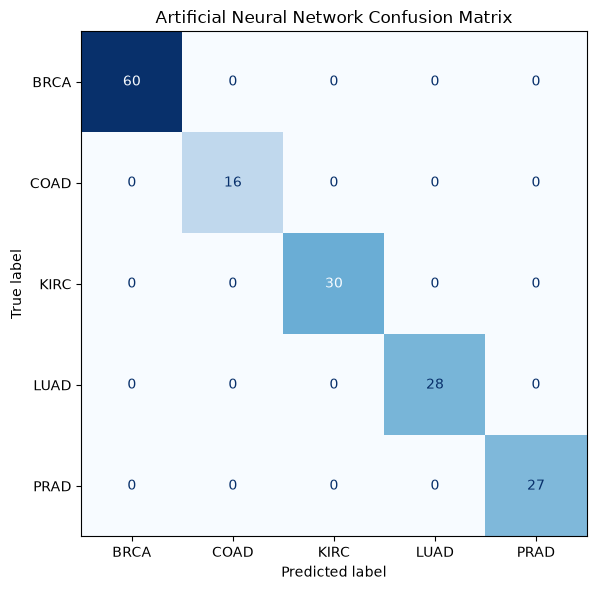

In [21]:
ann_cm = confusion_matrix(
    y_test,
    predictions
)

display = ConfusionMatrixDisplay(
    confusion_matrix=ann_cm,
    display_labels=label_encoder.classes_
)

fig, ax = plt.subplots(figsize=(8,6))

display.plot(
    cmap="Blues",
    ax=ax,
    colorbar=False
)

plt.title("Artificial Neural Network Confusion Matrix")

plt.tight_layout()

plt.savefig(
    "../results/figures/model_evaluation/ann_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "../results/figures/model_evaluation/ann_confusion_matrix.pdf",
    bbox_inches="tight"
)

plt.show()
plt.close()

## Training History

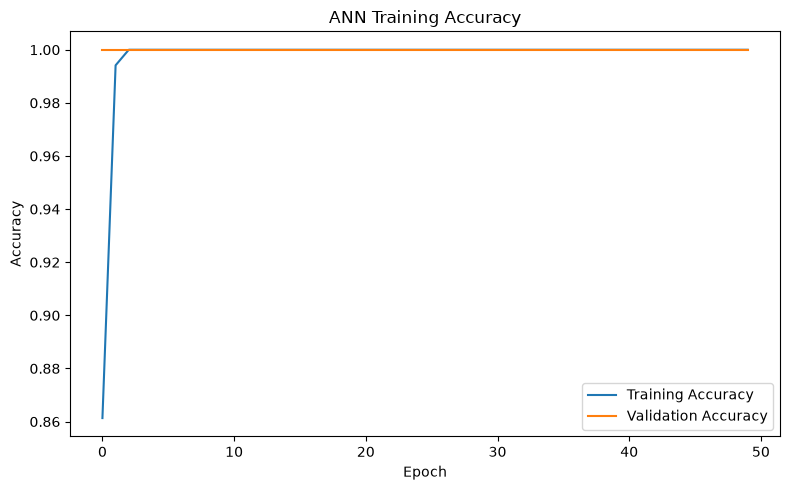

In [22]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("ANN Training Accuracy")

plt.legend()

plt.tight_layout()

plt.savefig(
    "../results/figures/model_evaluation/ann_accuracy_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "../results/figures/model_evaluation/ann_accuracy_curve.pdf",
    bbox_inches="tight"
)

plt.show()
plt.close()